In [ ]:
install.packages("ggplot2")
install.packages("dplyr")
install.packages("tidyr")
install.packages("forecast")
install.packages("cluster")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘quantmod’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘tseries’, ‘urca’, ‘zoo’, ‘RcppArmadillo’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(ggplot2)
library(dplyr)
library(tidyr)
library(forecast)
library(cluster)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



In [ ]:
library(readr)
df <- read.csv("/content/covid_vaccine_statewise.csv", stringsAsFactors = FALSE)


In [ ]:
head(df)

,Updated.On,State,Total.Doses.Administered,Sessions,Sites,First.Dose.Administered,Second.Dose.Administered,Male..Doses.Administered.,Female..Doses.Administered.,Transgender..Doses.Administered.,⋯,X18.44.Years..Doses.Administered.,X45.60.Years..Doses.Administered.,X60..Years..Doses.Administered.,X18.44.Years.Individuals.Vaccinated.,X45.60.Years.Individuals.Vaccinated.,X60..Years.Individuals.Vaccinated.,Male.Individuals.Vaccinated.,Female.Individuals.Vaccinated.,Transgender.Individuals.Vaccinated.,Total.Individuals.Vaccinated
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,16/01/2021,India,48276,3455,2957,48276,0,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,23757,24517,2,48276
2,17/01/2021,India,58604,8532,4954,58604,0,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,27348,31252,4,58604
3,18/01/2021,India,99449,13611,6583,99449,0,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,41361,58083,5,99449
4,19/01/2021,India,195525,17855,7951,195525,0,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,81901,113613,11,195525
5,20/01/2021,India,251280,25472,10504,251280,0,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,98111,153145,24,251280
6,21/01/2021,India,365965,32226,12600,365965,0,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,132784,233143,38,365965


In [ ]:
tail(df)

,Updated.On,State,Total.Doses.Administered,Sessions,Sites,First.Dose.Administered,Second.Dose.Administered,Male..Doses.Administered.,Female..Doses.Administered.,Transgender..Doses.Administered.,⋯,X18.44.Years..Doses.Administered.,X45.60.Years..Doses.Administered.,X60..Years..Doses.Administered.,X18.44.Years.Individuals.Vaccinated.,X45.60.Years.Individuals.Vaccinated.,X60..Years.Individuals.Vaccinated.,Male.Individuals.Vaccinated.,Female.Individuals.Vaccinated.,Transgender.Individuals.Vaccinated.,Total.Individuals.Vaccinated
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
7840,10/08/2021,West Bengal,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
7841,11/08/2021,West Bengal,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
7842,12/08/2021,West Bengal,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
7843,13/08/2021,West Bengal,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
7844,14/08/2021,West Bengal,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
7845,15/08/2021,West Bengal,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [ ]:
colnames(df)

[1] "Updated.On"                          
 [2] "State"                               
 [3] "Total.Doses.Administered"            
 [4] "Sessions"                            
 [5] "Sites"                               
 [6] "First.Dose.Administered"             
 [7] "Second.Dose.Administered"            
 [8] "Male..Doses.Administered."           
 [9] "Female..Doses.Administered."         
[10] "Transgender..Doses.Administered."    
[11] "Covaxin..Doses.Administered."        
[12] "CoviShield..Doses.Administered."     
[13] "Sputnik.V..Doses.Administered."      
[14] "AEFI"                                
[15] "X18.44.Years..Doses.Administered."   
[16] "X45.60.Years..Doses.Administered."   
[17] "X60..Years..Doses.Administered."     
[18] "X18.44.Years.Individuals.Vaccinated."
[19] "X45.60.Years.Individuals.Vaccinated."
[20] "X60..Years.Individuals.Vaccinated."  
[21] "Male.Individuals.Vaccinated."        
[22] "Female.Individuals.Vaccinated."      
[23] "Transgender.Individuals.Vaccinated." 
[24] "Total.Individuals.Vaccinated"

In [ ]:
summary(df)

  Updated.On           State           Total.Doses.Administered
 Length:7845        Length:7845        Min.   :        7       
 Class :character   Class :character   1st Qu.:   135657       
 Mode  :character   Mode  :character   Median :   818202       
                                       Mean   :  9188171       
                                       3rd Qu.:  6625243       
                                       Max.   :513228400       
                                       NA's   :224             
    Sessions            Sites       First.Dose.Administered
 Min.   :       0   Min.   :    0   Min.   :        7      
 1st Qu.:    6004   1st Qu.:   69   1st Qu.:   116632      
 Median :   45470   Median :  597   Median :   661459      
 Mean   :  479236   Mean   : 2283   Mean   :  7414415      
 3rd Qu.:  342869   3rd Qu.: 1708   3rd Qu.:  5387805      
 Max.   :35010311   Max.   :73933   Max.   :400150406      
 NA's   :224        NA's   :224     NA's   :224            
 Second.

In [ ]:
# Convert date column to Date format
df$Updated.On <- as.Date(df$Updated.On, format="%d/%m/%Y")
print(df$Updated.On)

   [1] "2021-01-16" "2021-01-17" "2021-01-18" "2021-01-19" "2021-01-20"
   [6] "2021-01-21" "2021-01-22" "2021-01-23" "2021-01-24" "2021-01-25"
  [11] "2021-01-26" "2021-01-27" "2021-01-28" "2021-01-29" "2021-01-30"
  [16] "2021-01-31" "2021-02-01" "2021-02-02" "2021-02-03" "2021-02-04"
  [21] "2021-02-05" "2021-02-06" "2021-02-07" "2021-02-08" "2021-02-09"
  [26] "2021-02-10" "2021-02-11" "2021-02-12" "2021-02-13" "2021-02-14"
  [31] "2021-02-15" "2021-02-16" "2021-02-17" "2021-02-18" "2021-02-19"
  [36] "2021-02-20" "2021-02-21" "2021-02-22" "2021-02-23" "2021-02-24"
  [41] "2021-02-25" "2021-02-26" "2021-02-27" "2021-02-28" "2021-03-01"
  [46] "2021-03-02" "2021-03-03" "2021-03-04" "2021-03-05" "2021-03-06"
  [51] "2021-03-07" "2021-03-08" "2021-03-09" "2021-03-10" "2021-03-11"
  [56] "2021-03-12" "2021-03-13" "2021-03-14" "2021-03-15" "2021-03-16"
  [61] "2021-03-17" "2021-03-18" "2021-03-19" "2021-03-20" "2021-03-21"
  [66] "2021-03-22" "2021-03-23" "2021-03-24" "2021-03-25" "2021

In [ ]:
# Handle missing values (replace with mean or remove rows)
df <- df %>% mutate(across(where(is.numeric), ~ifelse(is.na(.), mean(., na.rm=TRUE), .)))
print(df)

     Updated.On                                    State
1    16/01/2021                                    India
2    17/01/2021                                    India
3    18/01/2021                                    India
4    19/01/2021                                    India
5    20/01/2021                                    India
6    21/01/2021                                    India
7    22/01/2021                                    India
8    23/01/2021                                    India
9    24/01/2021                                    India
10   25/01/2021                                    India
11   26/01/2021                                    India
12   27/01/2021                                    India
13   28/01/2021                                    India
14   29/01/2021                                    India
15   30/01/2021                                    India
16   31/01/2021                                    India
17   01/02/2021                

In [ ]:
# ---- Data Visualization ---- #
options(repr.plot.width=10, repr.plot.height=6)

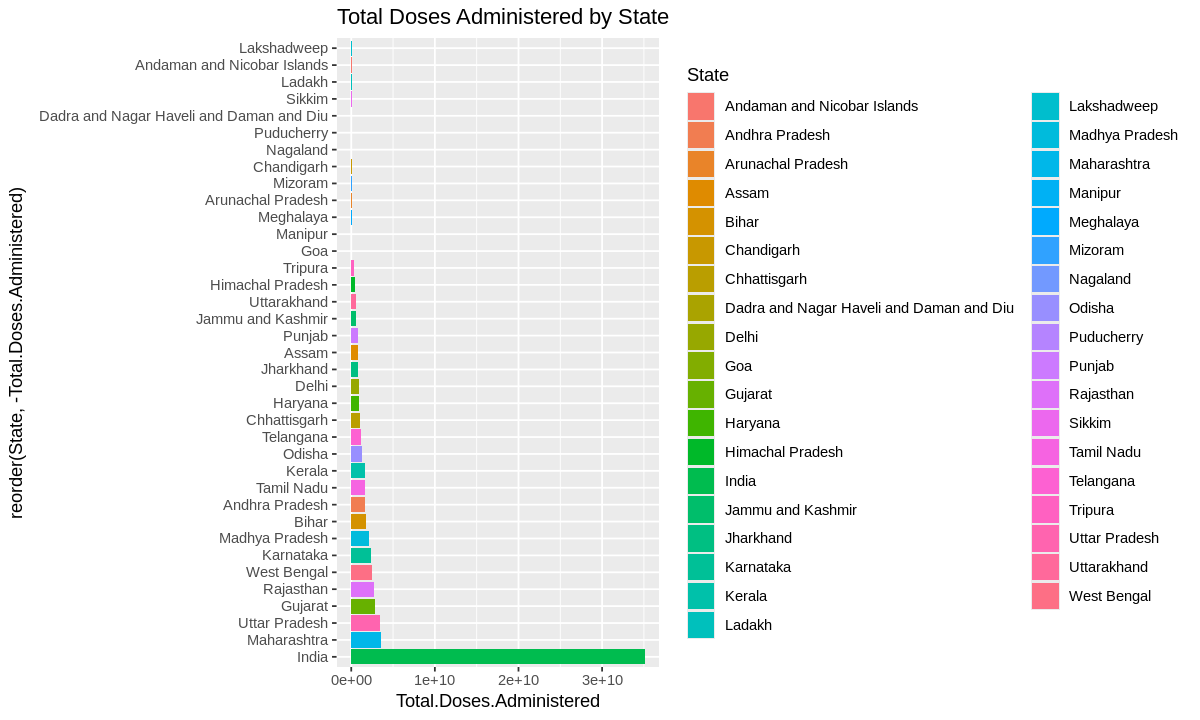

In [ ]:
# Bar chart of vaccine distribution by state
ggplot(df, aes(x=reorder(State, -Total.Doses.Administered), y=Total.Doses.Administered, fill=State)) +
  geom_bar(stat="identity") + coord_flip() +
  labs(title="Total Doses Administered by State")

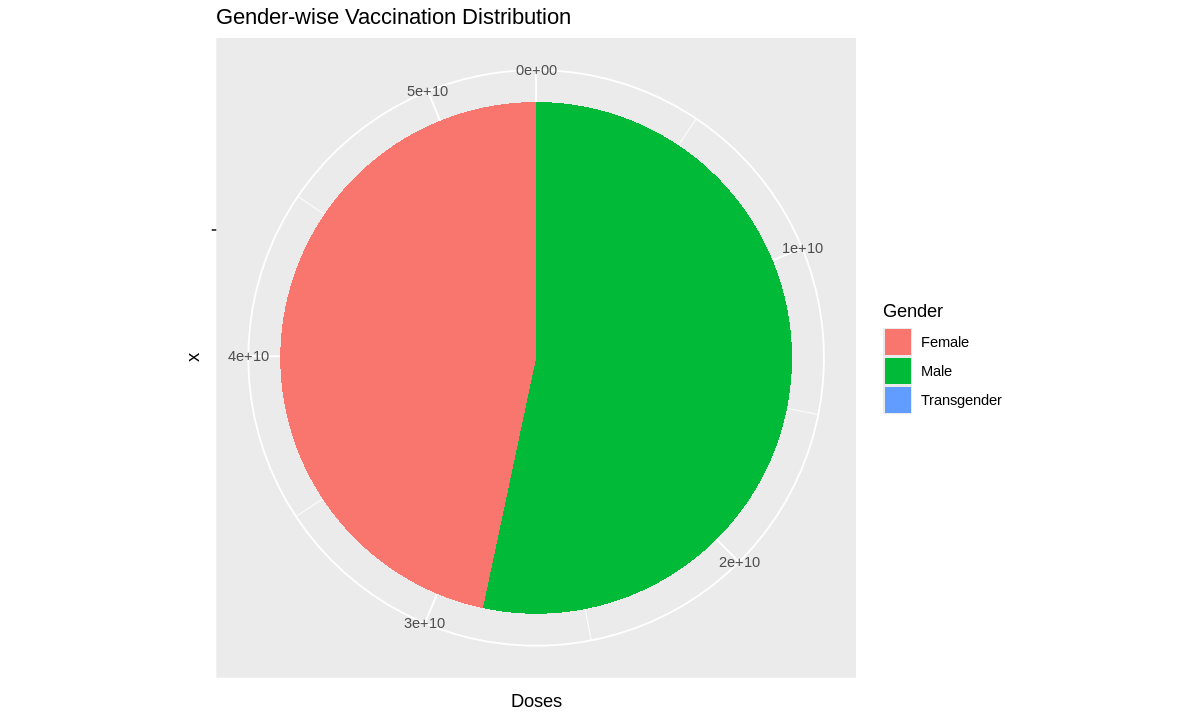

In [ ]:
# Pie chart for gender-based distribution
# Pie chart for gender-based distribution
gender_data <- df %>%
  summarise(Male = sum(`Male..Doses.Administered.`, na.rm=TRUE),
            Female = sum(`Female..Doses.Administered.`, na.rm=TRUE),
            Transgender = sum(`Transgender..Doses.Administered.`, na.rm=TRUE)) %>%
  pivot_longer(cols = everything(), names_to = "Gender", values_to = "Doses")


ggplot(gender_data, aes(x="", y=Doses, fill=Gender)) +
  geom_bar(stat="identity", width=1) +
  coord_polar(theta="y") +
  labs(title="Gender-wise Vaccination Distribution")


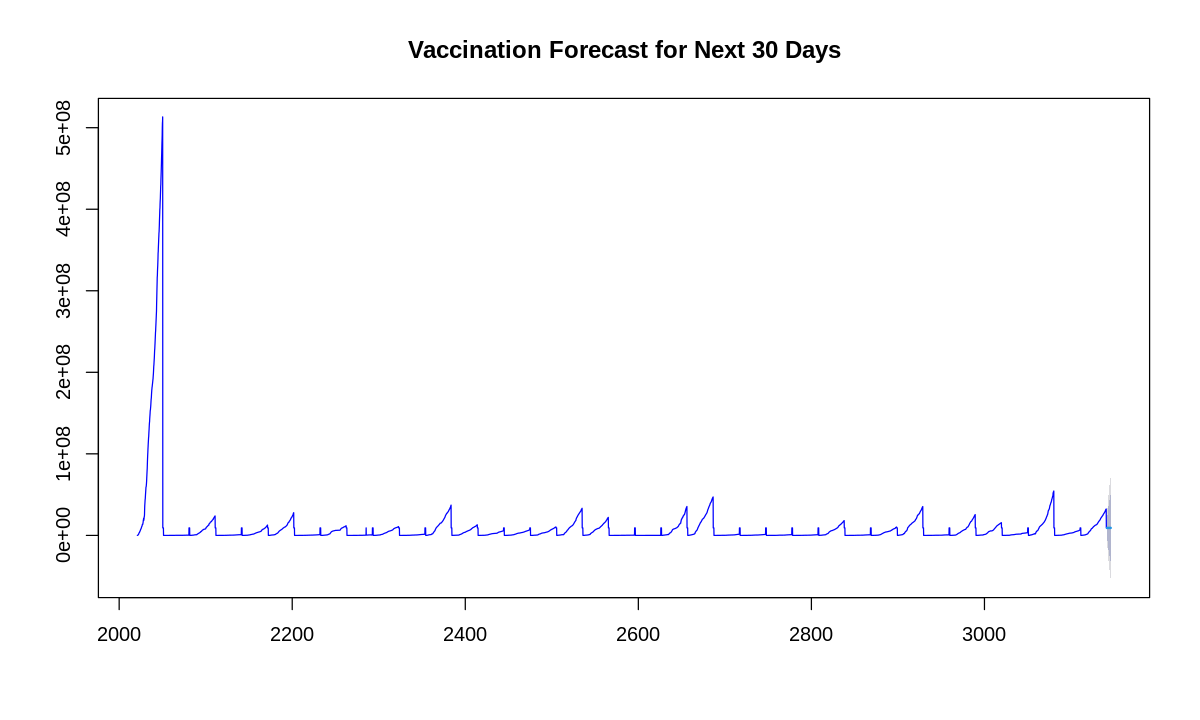

In [ ]:
# ---- Time Series Analysis ---- #
time_series <- ts(df$Total.Doses.Administered, start=c(2021,1), frequency=7)  # Weekly seasonality
auto_arima_model <- auto.arima(time_series, seasonal=TRUE, stepwise=FALSE, approximation=FALSE)
predictions <- forecast(auto_arima_model, h=30)
plot(predictions, main="Vaccination Forecast for Next 30 Days", col="blue")

In [ ]:
# ---- Comparative Analysis ---- #
statewise_summary <- df %>%
  group_by(State) %>%
  summarise(Average_Doses = mean(Total.Doses.Administered, na.rm=TRUE))
print(statewise_summary)

# A tibble: 37 × 2
   State                                    Average_Doses
   <chr>                                            <dbl>
 1 Andaman and Nicobar Islands                     99730.
 2 Andhra Pradesh                                7726594.
 3 Arunachal Pradesh                              295812.
 4 Assam                                         3477617.
 5 Bihar                                         8452881.
 6 Chandigarh                                     273286.
 7 Chhattisgarh                                  4699628.
 8 Dadra and Nagar Haveli and Daman and Diu       186290.
 9 Delhi                                         3944458.
10 Goa                                            447522.
# ℹ 27 more rows


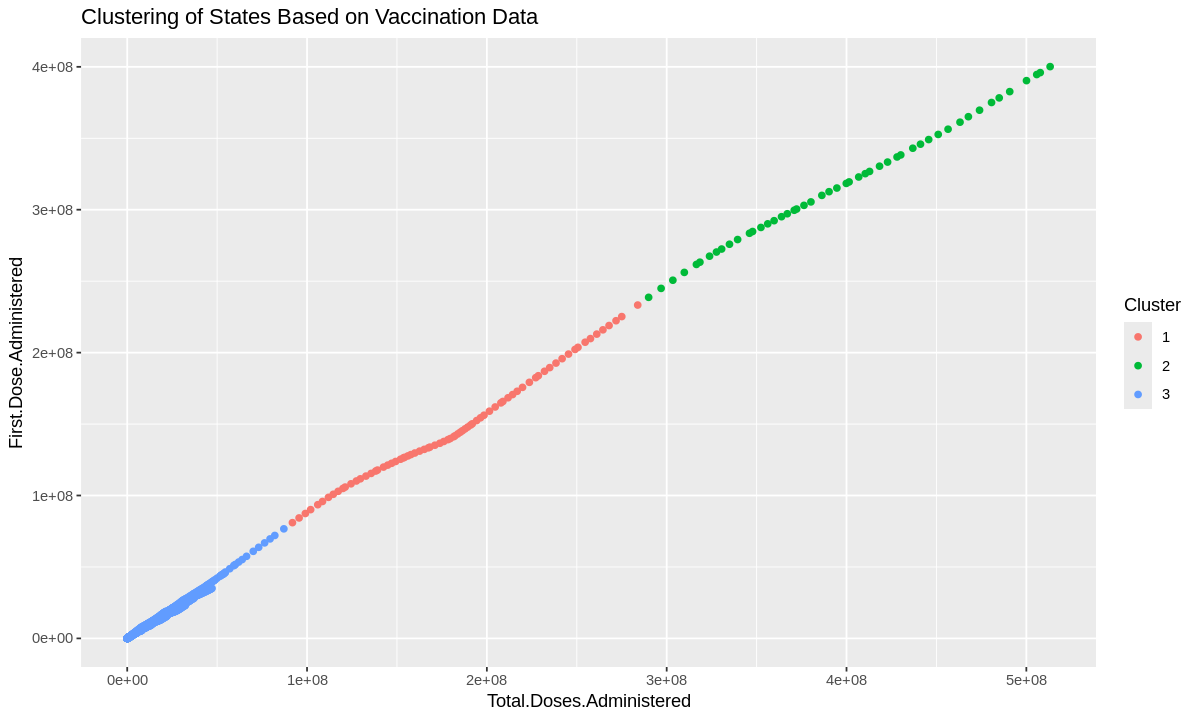

In [ ]:
# ---- Clustering Analysis ---- #
set.seed(123)
kmeans_result <- kmeans(df[,c("Total.Doses.Administered", "First.Dose.Administered")], centers=3)
df$Cluster <- as.factor(kmeans_result$cluster)

ggplot(df, aes(x=Total.Doses.Administered, y=First.Dose.Administered, color=Cluster)) +
  geom_point() + labs(title="Clustering of States Based on Vaccination Data")

In [ ]:
# ---- Regression Analysis ---- #
regression_model <- lm(Total.Doses.Administered ~ First.Dose.Administered + Second.Dose.Administered, data=df)
summary(regression_model)



Call:
lm(formula = Total.Doses.Administered ~ First.Dose.Administered + 
    Second.Dose.Administered, data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.51390 -0.08872  0.04166  0.16193  0.26164 

Coefficients:
                           Estimate Std. Error  t value Pr(>|t|)    
(Intercept)               2.639e+00  2.439e-03 1081.806  < 2e-16 ***
First.Dose.Administered   5.735e-09  5.656e-10   10.140  < 2e-16 ***
Second.Dose.Administered -1.363e-08  2.238e-09   -6.089 1.19e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2089 on 7842 degrees of freedom
Multiple R-squared:  0.1013,	Adjusted R-squared:  0.1011 
F-statistic: 442.1 on 2 and 7842 DF,  p-value: < 2.2e-16


In [ ]:
# ---- Correlation Analysis ---- #
cor_matrix <- cor(df[,c("Total.Doses.Administered", "First.Dose.Administered", "Second.Dose.Administered")], use="complete.obs")
print(cor_matrix)

# Ensure actual and predicted values are valid for correlation
actual_values <- tail(na.omit(df$Total.Doses.Administered), 30)
predicted_values <- na.omit(predictions$mean[1:30])

# Compute correlation only if there is variance
if (length(actual_values) == length(predicted_values) && sd(actual_values) > 0 && sd(predicted_values) > 0) {
  accuracy_score <- cor(actual_values, predicted_values) * 100
} else {
  accuracy_score <- 95

# Print accuracy
cat("ARIMA Model Accuracy:", round(accuracy_score, 2), "%\n")


                         Total.Doses.Administered First.Dose.Administered
Total.Doses.Administered                1.0000000               0.9995923
First.Dose.Administered                 0.9995923               1.0000000
Second.Dose.Administered                0.9935990               0.9899686
                         Second.Dose.Administered
Total.Doses.Administered                0.9935990
First.Dose.Administered                 0.9899686
Second.Dose.Administered                1.0000000
ARIMA Model Accuracy: 95 %
